# Cohort Analysis Project

### What is Cohort Analysis?

Cohort analysis is a method of grouping users based on a shared starting point (such as signup date or first purchase) and tracking how their behavior changes over time. It helps identify patterns in user retention, repeat activity, and overall engagement. 
By comparing cohorts, we can understand which user groups perform better and detect trends that are hidden in aggregated data.

In [7]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("../dataset/year_2009-2010.csv", encoding='latin1')

In [9]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom


In [10]:
df.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
96569,498488,21832,CHOCOLATE CALCULATOR,1,2/19/2010 10:55,3.36,NaN,United Kingdom
496303,535811,21391,FRENCH LAVENDER SCENT HEART,1,11/28/2010 15:18,2.10,15532.0,United Kingdom
253560,513811,21466,RED FLOWER CROCHET FOOD COVER,12,6/29/2010 9:39,3.75,14735.0,United Kingdom
233733,512049,22558,CLOTHES PEGS RETROSPOT PACK 24,12,6/13/2010 9:50,1.25,16292.0,United Kingdom
337253,522281,22599,CHRISTMAS MUSICAL ZINC STAR,2,9/13/2010 12:56,0.85,16374.0,United Kingdom


#### Dataset Description

The dataset contains online retail transactions with 8 columns: `Invoice`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `Price`, `Customer ID`, and `Country`. Each row represents a single purchased product, including details about the item, quantity, price, purchase date, customer, and country. This dataset is suitable for cohort analysis and customer behavior studies.

In [11]:
df.shape

(525461, 8)

The dataset contains 525,461 rows and 8 columns, which means we have a sufficiently large dataset for meaningful analysis.

In [12]:
orders=df[["InvoiceDate","Customer ID", "Price", "Quantity", "Invoice"]].copy()

We selected the following columns from the original dataframe to create the orders dataset: 

InvoiceDate, Customer ID, Price, Quantity, and Invoice. These fields contain all the essential information needed for our cohort analysis.

In [13]:
orders.head()

,InvoiceDate,Customer ID,Price,Quantity,Invoice
0,12/1/2009 7:45,13085.0,6.95,12,489434
1,12/1/2009 7:45,13085.0,6.75,12,489434
2,12/1/2009 7:45,13085.0,6.75,12,489434
3,12/1/2009 7:45,13085.0,2.10,48,489434
4,12/1/2009 7:45,13085.0,1.25,24,489434


In [14]:
orders.isna().mean()*100

InvoiceDate     0.000000
Customer ID    20.539488
Price           0.000000
Quantity        0.000000
Invoice         0.000000
dtype: float64

The dataset contains missing values only in the Customer ID column (20.54%). All other columns have no missing data.

In [15]:
orders=orders.dropna()

Since the missing values are only in the Customer ID column, we drop these rows to ensure the dataset is complete for analysis.

In [16]:
orders.shape

(417534, 5)

Now we have 417,534 rows and 5 columns

In [17]:
print(orders.duplicated().sum())

156219


In [18]:
orders=orders.drop_duplicates()

156,219 duplicate rows were identified and removed.

In [19]:
orders.shape

(261315, 5)

After removing the duplicate rows, we have 261,315 rows

In [20]:
orders["revenue"]=orders["Price"]*orders["Quantity"]

Created a new column `Revenue` by multiplying `Price` and `Quantity` for each transaction.
This represents the total amount spent per product in each order.

In [21]:
orders.rename(columns={"Customer ID":"customer_id", "InvoiceDate":"order_date", "Invoice": "order_id"}, inplace=True)
orders=orders.drop(columns=["Price", "Quantity"])

The dataset was cleaned by renaming columns for consistency, and unnecessary columns were dropped.

In [22]:
orders.head()

,order_date,customer_id,order_id,revenue
0,12/1/2009 7:45,13085.0,489434,83.4
1,12/1/2009 7:45,13085.0,489434,81.0
3,12/1/2009 7:45,13085.0,489434,100.8
4,12/1/2009 7:45,13085.0,489434,30.0
5,12/1/2009 7:45,13085.0,489434,39.6


In [23]:
orders.info()

<class 'pandas.DataFrame'>
Index: 261315 entries, 0 to 525460
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   order_date   261315 non-null  str    
 1   customer_id  261315 non-null  float64
 2   order_id     261315 non-null  str    
 3   revenue      261315 non-null  float64
dtypes: float64(2), str(2)
memory usage: 10.0 MB


In [24]:
orders["customer_id"]=orders["customer_id"].astype(int)
orders["order_date"]=pd.to_datetime(orders["order_date"])

The dataset was cleaned and prepared for analysis:
- `customer_id` was converted to `int` since all values are complete and represent whole numbers.
- `order_date` was converted to `datetime` to enable time-based analysis.
- `order_id` was kept as `str` because it serves as a unique identifier and may contain letters.

In [25]:
orders.info()

<class 'pandas.DataFrame'>
Index: 261315 entries, 0 to 525460
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   order_date   261315 non-null  datetime64[us]
 1   customer_id  261315 non-null  int64         
 2   order_id     261315 non-null  str           
 3   revenue      261315 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 10.0 MB


## Creating Cohorts

In [26]:
orders.sample(5)

,order_date,customer_id,order_id,revenue
202737,2010-05-19 10:33:00,16293,508915,21.90
203709,2010-05-19 15:47:00,13764,509030,4.25
304388,2010-08-13 12:05:00,14550,519121,9.90
430581,2010-11-03 12:45:00,16823,530529,3.90
205371,2010-05-20 18:18:00,12712,509195,10.14


In [27]:
first_order_date_by_customers = orders.groupby('customer_id')[
    'order_date'
].min()

In [28]:
first_order_date_by_customers.head()

customer_id
12346   2009-12-14 08:34:00
12347   2010-10-31 14:20:00
12348   2010-09-27 14:59:00
12349   2009-12-04 12:49:00
12351   2010-11-29 15:23:00
Name: order_date, dtype: datetime64[us]

In [29]:
first_order_date_by_customers.name = 'first_order_date'

To avoid duplicate `order_date` columns, we rename the `first_order_date` Series by changing its `.name` attribute.


In [30]:
first_order_date_by_customers.head()

customer_id
12346   2009-12-14 08:34:00
12347   2010-10-31 14:20:00
12348   2010-09-27 14:59:00
12349   2009-12-04 12:49:00
12351   2010-11-29 15:23:00
Name: first_order_date, dtype: datetime64[us]

In [31]:
orders = orders.join(first_order_date_by_customers,on='customer_id')

We joined the `first_order_date_by_customers` to the `orders` dataset on `customer_id` to add each customer's first order date to every transaction. 

In [32]:
orders.sample(10)

,order_date,customer_id,order_id,revenue,first_order_date
33266,2009-12-15 15:21:00,17841,492176,10.50,2009-12-02 15:41:00
219927,2010-06-03 13:08:00,13787,510763,18.95,2010-01-14 10:13:00
83197,2010-02-05 14:14:00,16704,497035,5.95,2010-02-05 14:14:00
12274,2009-12-05 13:32:00,12359,490382,30.00,2009-12-05 13:32:00
8560,2009-12-03 15:43:00,12937,490085,5.20,2009-12-03 15:43:00
440683,2010-11-08 10:07:00,12435,531395,101.76,2009-12-02 13:58:00
383122,2010-10-10 14:30:00,14390,526217,11.90,2010-10-10 14:30:00
103645,2010-02-25 18:58:00,14770,499284,17.00,2010-02-25 18:58:00
403376,2010-10-20 11:32:00,13557,528040,19.80,2009-12-08 17:41:00
488635,2010-11-25 12:28:00,16709,535235,38.25,2009-12-09 13:16:00


## Creating monthly periods for cohort analysis

In [33]:

orders['first_order_month'] = orders['first_order_date'].dt.to_period('M')
orders['order_month'] = orders['order_date'].dt.to_period('M')

We created two new columns to work with monthly data:
- `first_order_month` shows the month of each customer's first order.
- `order_month` shows the month of each individual order.

In [34]:
orders["first_order_month"].nunique()

13

We calculated the number of unique first order months using `orders["first_order_month"].nunique()` to understand how many different cohorts (by month) are present in the dataset. The dataset contains 13 cohorts

In [35]:
cohort_grouped = orders.groupby('first_order_month').agg(
    {'order_id': 'nunique', 'customer_id': 'nunique', 'revenue': 'sum'}
).rename(columns={"order_id": "uni_num_order", "customer_id": "uni_num_customer"}).reset_index().sort_values("first_order_month")



We grouped the dataset by `first_order_month` to create monthly customer cohorts.  
For each cohort, we calculated:
- the number of unique orders (`uni_num_order`),
- the number of unique customers (`uni_num_customer`),
- and the total revenue.

In [36]:
cohort_grouped

,first_order_month,uni_num_order,uni_num_customer,revenue
0,2009-12,12005,1045,3580255.055
1,2010-01,2241,394,515696.174
2,2010-02,1812,363,393460.453
3,2010-03,2016,436,432898.781
4,2010-04,1011,291,193367.701
5,2010-05,774,254,162230.440
6,2010-06,819,269,143746.490
7,2010-07,606,183,104255.290
8,2010-08,472,158,89270.660
9,2010-09,575,242,159019.130


Early cohorts (especially December 2009) have significantly higher customer counts, orders, and revenue, while later cohorts show a steady decline in activity and value.

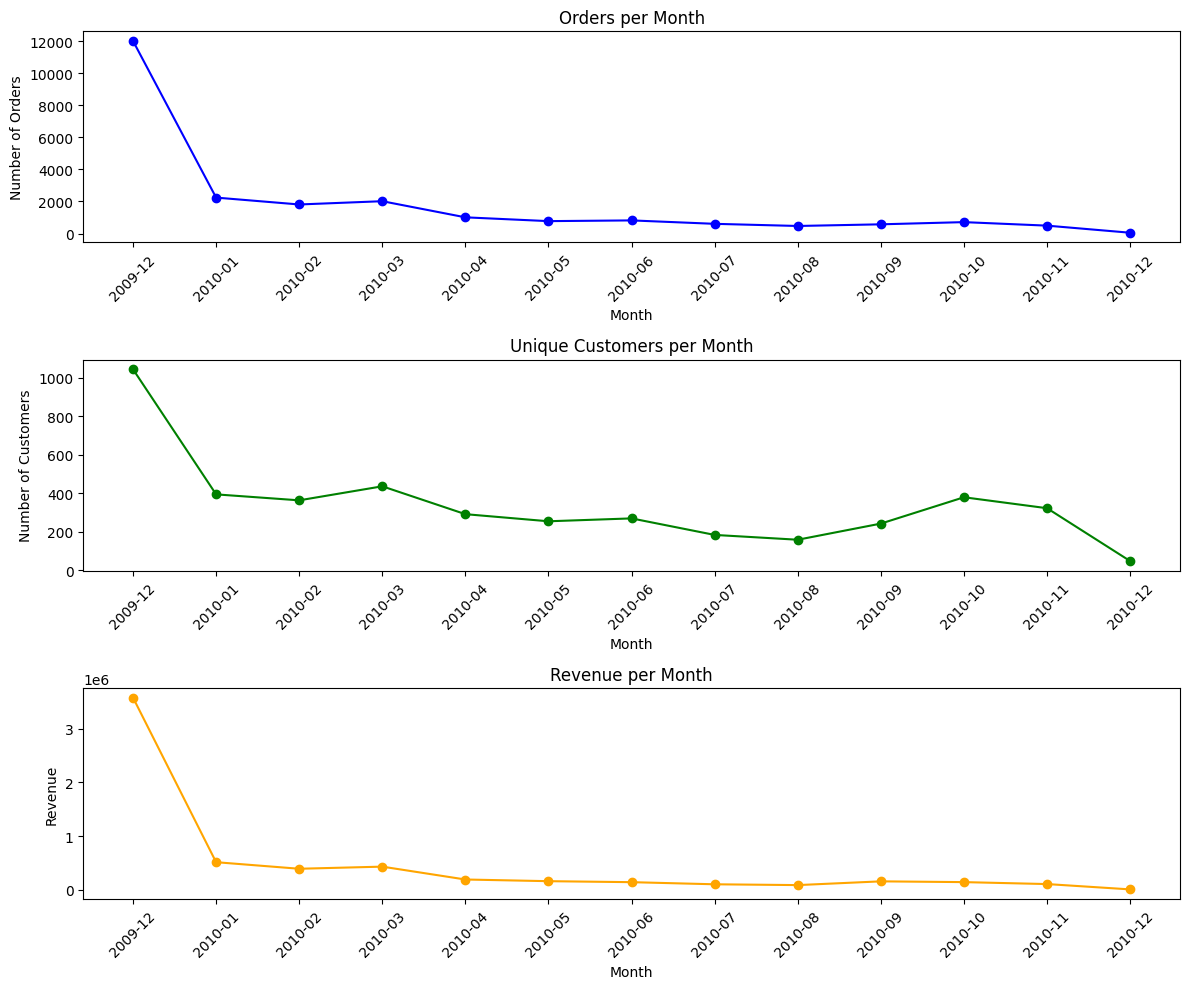

In [37]:

cohort_grouped['first_order_month'] = cohort_grouped['first_order_month'].astype(str)
plt.figure(figsize=(12, 10))

# Plot 1: Orders
plt.subplot(3, 1, 1)
plt.plot(cohort_grouped['first_order_month'], cohort_grouped['uni_num_order'], marker='o', color='blue')
plt.title('Orders per Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

# Plot 2: Customers
plt.subplot(3, 1, 2)
plt.plot(cohort_grouped['first_order_month'], cohort_grouped['uni_num_customer'], marker='o', color='green')
plt.title('Unique Customers per Month')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

# Plot 3: Revenue
plt.subplot(3, 1, 3)
plt.plot(cohort_grouped['first_order_month'], cohort_grouped['revenue'], marker='o', color='orange')
plt.title('Revenue per Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

# Adjust layout and display
plt.tight_layout()
plt.show()




We converted `first_order_month` to string because Matplotlib cannot plot Period objects reliably. Converting to string ensures that the month labels appear correctly on the x-axis.

### Relative Value

Relative value measures the ratio between two related metrics.  
For example, dividing the total revenue of all purchases by the number of purchases gives the **average price per product**. This is a relative value because it compares two connected measures: **total revenue and number of purchases**.

**Rule:** Components must be related.  
- Total revenue ÷ number of purchases → meaningful  
- Number of purchases ÷ steps taken to reach the store → not meaningful  

**Cohort Analysis Example:**  
- Customers who made their first purchase in January 2010: how many returned in February, March, and the following months?  
- Are customers acquired in different months equally active over time?  

This information shows **customer loyalty, purchase frequency, and cohort behavior over time**.  
Such analysis helps shape business strategy, e.g., identifying which customers to target more effectively.


In [38]:
orders.pivot_table(
    index='first_order_month',
    columns='order_month',
    values='customer_id',
    aggfunc='nunique',
)

order_month,2009-12,2010-01,2010-02,2010-03,2010-04,2010-05,2010-06,2010-07,2010-08,2010-09,2010-10,2010-11,2010-12
first_order_month,,,,,,,,,,,,,
2009-12,1045.0,392.0,358.0,447.0,410.0,408.0,408.0,374.0,355.0,392.0,452.0,518.0,260.0
2010-01,NaN,394.0,86.0,119.0,120.0,110.0,115.0,105.0,91.0,114.0,134.0,122.0,37.0
2010-02,NaN,NaN,363.0,109.0,82.0,110.0,93.0,76.0,79.0,103.0,100.0,106.0,32.0
2010-03,NaN,NaN,NaN,436.0,95.0,113.0,103.0,100.0,87.0,105.0,130.0,126.0,36.0
2010-04,NaN,NaN,NaN,NaN,291.0,67.0,58.0,47.0,54.0,67.0,79.0,76.0,22.0
2010-05,NaN,NaN,NaN,NaN,NaN,254.0,49.0,45.0,49.0,48.0,66.0,56.0,22.0
2010-06,NaN,NaN,NaN,NaN,NaN,NaN,269.0,58.0,53.0,55.0,62.0,76.0,20.0
2010-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,183.0,38.0,37.0,52.0,55.0,21.0
2010-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158.0,39.0,50.0,51.0,20.0



- **First Purchase Activity:** Cohorts show the highest activity in their first purchase month (e.g., December 2009 cohort has 1,045 customers). Activity decreases in subsequent months.  
- **Retention Trend:** The December 2009 cohort remains active up to December 2010 (260 customers), whereas later cohorts lose activity faster (e.g., June 2010 cohort has only 20 customers by December 2010).  
- **Average Purchase Duration:** Most cohorts see a sharp drop in activity after the first 2–3 months (e.g., January 2010 cohort decreases from 394 to 37 customers).  
- **New Cohorts:** Recent cohorts (Oct–Nov 2010) attract new customers, but their long-term retention is still uncertain.

**Conclusion:**

- Customers are typically active for a few months after their first purchase before activity declines.  
- Early cohorts (e.g., Dec 2009) exhibit longer-term loyalty, while later cohorts fade faster.  
- Strengthening customer retention strategies (discounts, loyalty programs) can help improve activity in newer cohorts.

### ARPU (Average Revenue Per User)

Another key aspect of cohort analysis is tracking **average revenue per user (ARPU)** over time.  
ARPU is calculated as the **total revenue divided by the number of unique customers**.  

This metric helps us understand whether the **revenue generated per active customer is increasing**, indicating whether returning users are spending more over time.



The following code calculates **monthly cohort metrics**:


In [39]:
orders_grouped_by_cohorts = orders.groupby(
    ['first_order_month', 'order_month']
).agg({'revenue': 'sum', 'customer_id': 'nunique'}
).rename(columns={"customer_id": "uni_num_customer"})

orders_grouped_by_cohorts.head()

revenue  uni_num_customer
first_order_month order_month                              
2009-12           2009-12      490338.860              1045
                  2010-01      280578.401               392
                  2010-02      210385.052               358
                  2010-03      282046.130               447
                  2010-04      222642.450               410


To focus on a single cohort (e.g., October 2010), we use:

In [40]:
orders_grouped_by_cohorts.loc["2010-10"].sort_values("uni_num_customer", ascending=False)

,revenue,uni_num_customer
order_month,,
2010-10,110240.75,379
2010-11,28520.89,112
2010-12,5916.83,39


#### We can calculate the **average revenue per user (ARPU)** for each cohort month by dividing total revenue by the number of unique customers:

- **ARPU per month** = total revenue ÷ number of unique customers  
- **Relative to first purchase month**: track how ARPU changes in the months following the cohort's first order.  

This helps us understand how much revenue each active customer generates over time and how user value evolves across cohorts.

In [41]:
orders_grouped_by_cohorts["revenue_per_user"]=orders_grouped_by_cohorts["revenue"]/orders_grouped_by_cohorts["uni_num_customer"]

Created a pivot table to visualize **average revenue per user (ARPU) for each cohort**:


In [42]:
orders_grouped_by_cohorts.pivot_table(
    index='first_order_month',
    columns='order_month',
    values='revenue_per_user',
    aggfunc='mean',
)

order_month,2009-12,2010-01,2010-02,2010-03,2010-04,2010-05,2010-06,2010-07,2010-08,2010-09,2010-10,2010-11,2010-12
first_order_month,,,,,,,,,,,,,
2009-12,469.223789,715.761227,587.667743,630.975682,543.030366,517.462181,562.909681,591.115856,662.892789,674.756786,743.189093,853.315988,594.709077
2010-01,NaN,272.450155,322.053500,304.323277,333.827258,349.116636,392.861391,301.516667,324.030330,337.505272,412.778657,448.027049,302.846757
2010-02,NaN,NaN,293.594829,199.739817,431.728415,323.958636,299.822796,343.633684,304.378354,319.917767,364.464400,375.714811,212.731250
2010-03,NaN,NaN,NaN,244.452204,329.943053,283.962301,363.196990,309.760900,414.214828,402.117810,412.486538,413.116270,293.470833
2010-04,NaN,NaN,NaN,NaN,228.395811,170.571194,231.085690,392.219362,280.830556,313.520000,286.157722,281.933553,156.130455
2010-05,NaN,NaN,NaN,NaN,NaN,309.752244,225.435714,224.684444,191.758980,252.899167,335.880909,280.926071,134.585000
2010-06,NaN,NaN,NaN,NaN,NaN,NaN,157.517212,123.066897,286.868491,293.789636,337.259355,451.158289,383.795500
2010-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,269.040273,141.603421,249.214865,309.085577,354.275091,231.498095
2010-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,246.891203,256.250256,351.708400,334.896667,280.147000


Cohort analysis shows how **average revenue per user (ARPU)** varies across cohorts and over time:

- **Overall Trend:** Older cohorts (e.g., Dec 2009) tend to generate higher ARPU in subsequent months compared to newer cohorts.  
  - Example: In Dec 2010, the Dec 2009 cohort ARPU = 594.71, while the Dec 2010 cohort ARPU = 195.21.  
- **First Month Differences:** Initial month ARPU varies across cohorts; some newer cohorts start with relatively high ARPU.  
  - Example: Sep 2010 cohort starts with ARPU = 473.37.  
- **Variability:** ARPU fluctuates within cohorts; there is no consistent upward or downward trend month to month.  
- **Influencing Factors:** Differences may result from purchase timing, seasonality, or changes in customer acquisition strategies.

**Conclusion:**  
- Older cohorts maintain relatively higher revenue per customer in later months.  
- Newer cohorts may start strong but ARPU tends to be lower over time.  
- Cohort analysis helps identify **customer value trends** and informs **retention strategies**.

# **Lifetime**

In the context of cohorts, the **lifetime concept** is used to evaluate changes in **average revenue per user (ARPU)** over time since a customer’s **first purchase**.  

- It measures **which month relative to the cohort's first order** a particular event (e.g., revenue generation) occurs.  
- This allows tracking **customer value evolution** and understanding how ARPU develops over the customer’s lifetime within a cohort.

In [43]:
orders_grouped_by_cohorts = orders_grouped_by_cohorts.reset_index()
orders_grouped_by_cohorts['cohort_lifetime'] = (
    orders_grouped_by_cohorts['order_month']
    - orders_grouped_by_cohorts['first_order_month']
)
orders_grouped_by_cohorts['cohort_lifetime']=orders_grouped_by_cohorts['cohort_lifetime'].apply(lambda x: x.n)

In [44]:
orders_grouped_by_cohorts.sample(5)

,first_order_month,order_month,revenue,uni_num_customer,revenue_per_user,cohort_lifetime
25,2010-02,2010-02,106574.923,363,293.594829,0
72,2010-07,2010-09,9220.950,37,249.214865,2
44,2010-03,2010-11,52052.650,126,413.116270,8
41,2010-03,2010-08,36036.690,87,414.214828,5
86,2010-10,2010-11,28520.890,112,254.650804,1


In [45]:
orders_grouped_by_cohorts.sort_values("cohort_lifetime", ascending=False).head()


,first_order_month,order_month,revenue,uni_num_customer,revenue_per_user,cohort_lifetime
12,2009-12,2010-12,154624.360,260,594.709077,12
11,2009-12,2010-11,442017.682,518,853.315988,11
24,2010-01,2010-12,11205.330,37,302.846757,11
23,2010-01,2010-11,54659.300,122,448.027049,10
10,2009-12,2010-10,335921.470,452,743.189093,10


In [46]:
revenue_per_user_pivot = orders_grouped_by_cohorts.pivot_table(
    index='first_order_month',
    columns='cohort_lifetime',
    values='revenue_per_user',
    aggfunc='mean',
)
revenue_per_user_pivot

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11,12
first_order_month,,,,,,,,,,,,,
2009-12,469.223789,715.761227,587.667743,630.975682,543.030366,517.462181,562.909681,591.115856,662.892789,674.756786,743.189093,853.315988,594.709077
2010-01,272.450155,322.053500,304.323277,333.827258,349.116636,392.861391,301.516667,324.030330,337.505272,412.778657,448.027049,302.846757,NaN
2010-02,293.594829,199.739817,431.728415,323.958636,299.822796,343.633684,304.378354,319.917767,364.464400,375.714811,212.731250,NaN,NaN
2010-03,244.452204,329.943053,283.962301,363.196990,309.760900,414.214828,402.117810,412.486538,413.116270,293.470833,NaN,NaN,NaN
2010-04,228.395811,170.571194,231.085690,392.219362,280.830556,313.520000,286.157722,281.933553,156.130455,NaN,NaN,NaN,NaN
2010-05,309.752244,225.435714,224.684444,191.758980,252.899167,335.880909,280.926071,134.585000,NaN,NaN,NaN,NaN,NaN
2010-06,157.517212,123.066897,286.868491,293.789636,337.259355,451.158289,383.795500,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,269.040273,141.603421,249.214865,309.085577,354.275091,231.498095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,246.891203,256.250256,351.708400,334.896667,280.147000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



##### The data shows how **average revenue per user (ARPU)** changes over time for different cohorts. Some cohorts see an increase after their first month, while others experience a decrease:

- **Dec 2009 Cohort:** ARPU in the first month = 469.22, in the second month = 715.76 → significant increase.  
- **Jan 2010 Cohort:** ARPU in the first month = 272.45, in the second month = 322.05 → moderate increase.  
- **Feb 2010 Cohort:** ARPU in the first month = 293.59, in the second month = 199.74 → decrease, indicating lower revenue per user.

##### It is difficult to draw strong conclusions from this table alone: the values look similar, and no clear pattern stands out at first glance. However, if we convert the table into a **heatmap**, trends and anomalies become much easier to see.


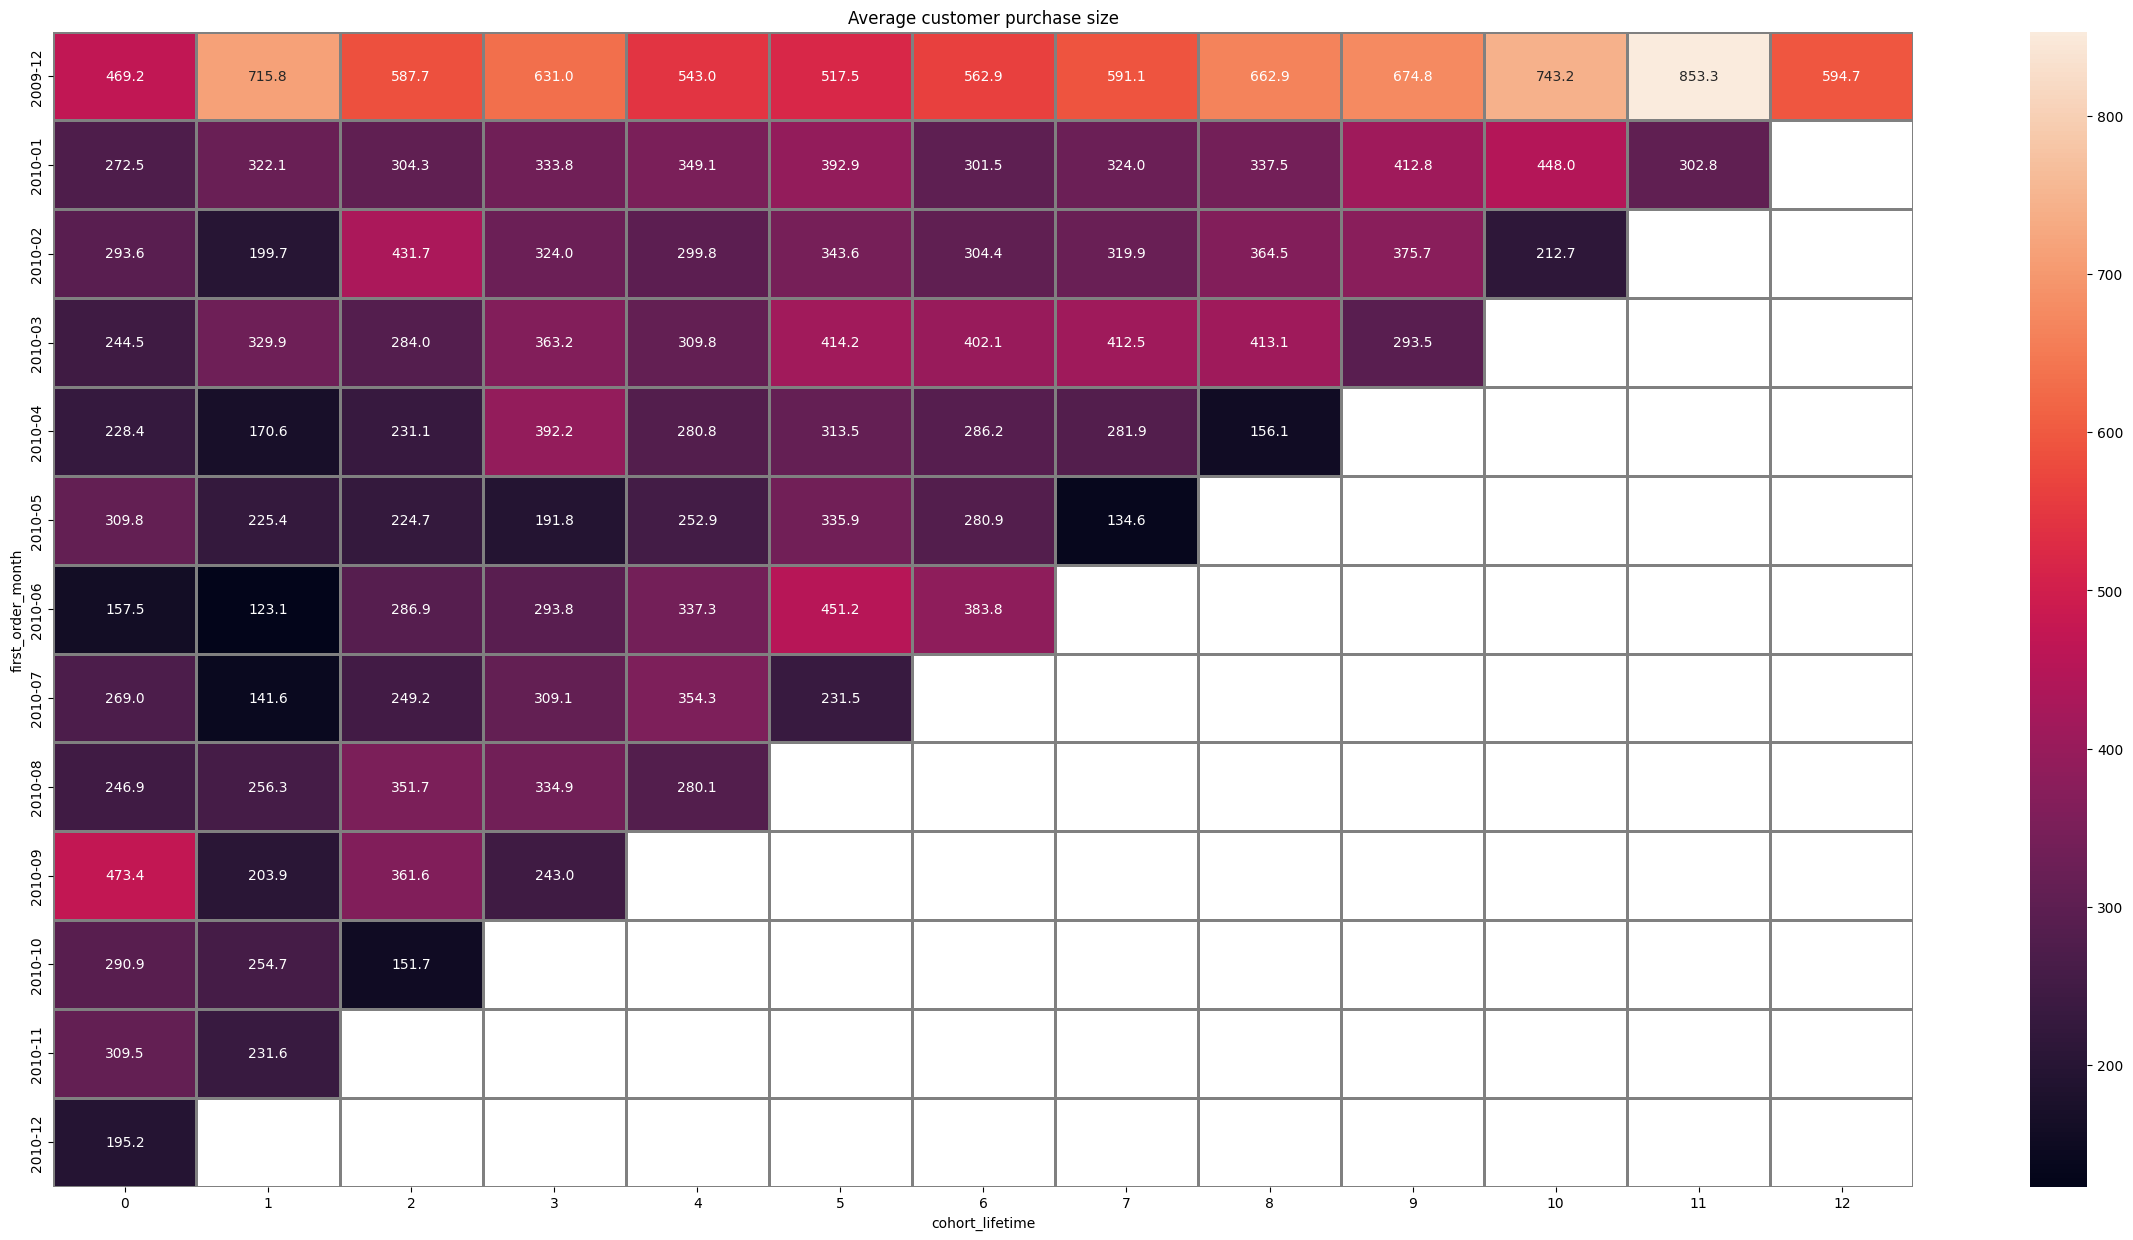

In [47]:
import seaborn as sns
from matplotlib import pyplot as plt
plt.figure(figsize=(30, 15))
plt.title('Average customer purchase size')
sns.heatmap(
    revenue_per_user_pivot,
    annot=True,
    fmt='.1f',
    linewidths=1,
    linecolor='gray',
);

## **Retention Rate**

Retention rate shows what percentage of customers from a given cohort remain active over time.

- **Lifetime 0:** The month of the first purchase — this is always **100% retention**, because all customers in the cohort make at least one purchase in that month.
- **Lifetime 1:** Shows what percentage of the same cohort returned and made a purchase in the following month.
- **Lifetime 2+ :** Indicates how many customers stayed active in later months, helping us measure long-term loyalty.


**Retention Rate at _n_-th month:**

$$
\text{RetentionRate}_{n} \;=\;
\frac{\displaystyle \text{ActiveUsers}_{n}}
     {\displaystyle \text{ActiveUsers}_{0}}
\times 100\%
$$


Companies may prefer calculating the Retention Rate on a weekly basis instead of a monthly basis because they want to see results faster. Monthly insights take too long to reflect user behavior, so weekly cohorts allow them to track performance more frequently and make quicker data-driven decisions.

In [48]:
orders.head()

,order_date,customer_id,order_id,revenue,first_order_date,first_order_month,order_month
0,2009-12-01 07:45:00,13085,489434,83.4,2009-12-01 07:45:00,2009-12,2009-12
1,2009-12-01 07:45:00,13085,489434,81.0,2009-12-01 07:45:00,2009-12,2009-12
3,2009-12-01 07:45:00,13085,489434,100.8,2009-12-01 07:45:00,2009-12,2009-12
4,2009-12-01 07:45:00,13085,489434,30.0,2009-12-01 07:45:00,2009-12,2009-12
5,2009-12-01 07:45:00,13085,489434,39.6,2009-12-01 07:45:00,2009-12,2009-12


In [49]:
orders.drop(columns={"first_order_month", "order_month"}, inplace=True)

In [50]:
orders.sample(7)

,order_date,customer_id,order_id,revenue,first_order_date
292103,2010-08-02 14:02:00,13357,517859,5.10,2010-03-22 14:30:00
12737,2009-12-06 11:27:00,17244,490405,2.50,2009-12-06 11:27:00
303138,2010-08-12 14:57:00,15365,518945,29.70,2010-02-04 16:43:00
416932,2010-10-27 09:52:00,12563,529201,19.80,2010-10-27 09:52:00
369893,2010-10-04 08:21:00,18276,525090,10.20,2009-12-10 17:14:00
87028,2010-02-10 11:21:00,14593,497504,12.75,2009-12-09 12:57:00
308604,2010-08-18 09:19:00,14156,519514,333.60,2009-12-01 12:30:00


In [51]:
orders['order_date'].dt.weekday.head()

0    1
1    1
3    1
4    1
5    1
Name: order_date, dtype: int32

### This shows the weekday index (0–6) of the first few orders:

- 0 = Monday  
- 1 = Tuesday  
- 2 = Wednesday  
- 3 = Thursday  
- 4 = Friday  
- 5 = Saturday  
- 6 = Sunday  

It provides a quick view of which weekdays the orders were placed.

#### Week Start Date for Each Order

In [52]:
orders['buy_week'] = (orders['order_date']- pd.to_timedelta(orders['order_date'].dt.weekday, unit='D')).dt.normalize()

The `buy_week` column calculates the start of the week (Monday) for each `order_date` based on its weekday.  
- Subtracting `weekday` from `order_date` shifts each date to the **Monday of that week**.  
  - Monday (0) → 0 days subtracted → same date  
  - Tuesday (1) → 1 day subtracted → Monday  
  - Wednesday (2) → 2 days subtracted → Monday  
  - …  
  - Sunday (6) → 6 days subtracted → previous Monday  

This aligns all dates to the **week start**, so each week runs Monday → Sunday.

In [53]:
orders.sample(5)

,order_date,customer_id,order_id,revenue,first_order_date,buy_week
294135,2010-08-04 09:39:00,14225,518008,39.6,2010-01-12 15:02:00,2010-08-02
397927,2010-10-18 08:42:00,12376,527439,100.8,2010-10-18 08:42:00,2010-10-18
259786,2010-07-02 14:15:00,16409,514480,1.7,2009-12-13 15:38:00,2010-06-28
415608,2010-10-26 13:44:00,13578,529094,40.8,2010-10-26 13:44:00,2010-10-25
381705,2010-10-08 16:37:00,13541,526160,39.0,2010-05-18 16:15:00,2010-10-04


In [54]:
orders['first_buy_week'] = (orders['first_order_date']- pd.to_timedelta(orders['first_order_date'].dt.weekday, unit='D')).dt.normalize()

- **`buy_week`** → Shows the **Monday of the week** for each individual purchase. Each order gets mapped to the start of its corresponding week.  
- **`first_buy_week`** → Shows the **Monday of the week** when a customer made their **first-ever purchase**. Only the first order of each customer is considered.  


In [55]:
orders['cohort_lifetime'] = (orders['buy_week'] - orders['first_buy_week'])

- `cohort_lifetime` calculates the difference between the order’s week (`buy_week`) and the customer’s first purchase week (`first_buy_week`).  
- Unlike monthly cohorts, this measures the **number of weeks since the customer’s first purchase**, enabling weekly cohort analysis and tracking retention or revenue on a weekly basis.

In [56]:
orders.sample(5)

,order_date,customer_id,order_id,revenue,first_order_date,buy_week,first_buy_week,cohort_lifetime
190528,2010-05-09 15:06:00,12748,507420,1.65,2009-12-04 17:31:00,2010-05-03,2009-11-30,154 days
90360,2010-02-14 15:22:00,17841,497918,3.30,2009-12-02 15:41:00,2010-02-08,2009-11-30,70 days
192971,2010-05-11 10:50:00,16945,507700,19.50,2009-12-09 11:33:00,2010-05-10,2009-12-07,154 days
494798,2010-11-28 12:15:00,14546,535677,7.95,2009-12-06 13:10:00,2010-11-22,2009-11-30,357 days
74112,2010-01-28 19:41:00,15861,496086,3.38,2010-01-28 19:41:00,2010-01-25,2010-01-25,0 days


In [57]:
orders['cohort_lifetime'] = orders['cohort_lifetime'] / np.timedelta64(1, 'W')
orders['cohort_lifetime'] = orders['cohort_lifetime'].astype(int)

- Here, we converted the difference between each purchase week and the customer’s first purchase week into **full weeks**.  
- We did this so that we can **measure the cohort’s age in complete weeks**, which makes weekly cohort analysis easier and more consistent.  
- By using integers, each cohort’s behavior over time can be clearly tracked and compared without dealing with fractional weeks.

In [58]:
orders.sample(5)

,order_date,customer_id,order_id,revenue,first_order_date,buy_week,first_buy_week,cohort_lifetime
489647,2010-11-25 13:51:00,14415,535274,18.60,2009-12-16 14:08:00,2010-11-22,2009-12-14,49
28818,2009-12-14 13:11:00,17318,491807,4.75,2009-12-14 13:11:00,2009-12-14,2009-12-14,0
505278,2010-12-01 16:17:00,17690,536580,12.60,2010-02-03 14:26:00,2010-11-29,2010-02-01,43
25665,2009-12-11 14:20:00,13415,491622,5.10,2009-12-11 14:20:00,2009-12-07,2009-12-07,0
521310,2010-12-08 14:22:00,13523,537822,15.00,2010-11-02 14:55:00,2010-12-06,2010-11-01,5


In [59]:
cohorts=orders.groupby(["first_buy_week", "cohort_lifetime"]).agg({"customer_id": "nunique"}).reset_index()

cohorts.head()

,first_buy_week,cohort_lifetime,customer_id
0,2009-11-30,0,469
1,2009-11-30,1,131
2,2009-11-30,2,126
3,2009-11-30,3,29
4,2009-11-30,5,60


To calculate the **Retention Rate**, we first need to determine the initial number of users in each cohort. Then, for each subsequent week, we divide the number of active users by this initial count.

The initial user count for each cohort can be obtained by looking at **week 0**:

- **Week 0:** Represents the first week when the cohort made their initial purchase, giving the baseline number of users.

In [60]:
cohort_0_number=cohorts[cohorts["cohort_lifetime"]==0][["first_buy_week","customer_id"]].rename(columns={"customer_id": "first_week_customer"})

cohort_0_number.head()  

,first_buy_week,first_week_customer
0,2009-11-30,469
53,2009-12-07,367
105,2009-12-14,192
156,2009-12-21,17
193,2010-01-04,66


Next, we combine the cohort data with the initial user count for each cohort. This time, instead of using `join()`, we use the `merge()` method

In [61]:
cohorts = cohorts.merge(cohort_0_number, on='first_buy_week')

In [62]:
cohorts.head()

,first_buy_week,cohort_lifetime,customer_id,first_week_customer
0,2009-11-30,0,469,469
1,2009-11-30,1,131,469
2,2009-11-30,2,126,469
3,2009-11-30,3,29,469
4,2009-11-30,5,60,469


Now we are ready to calculate Retention rate:

In [63]:
cohorts['retention'] = (cohorts['customer_id'] / cohorts['first_week_customer'])

In [64]:
cohorts.head()

,first_buy_week,cohort_lifetime,customer_id,first_week_customer,retention
0,2009-11-30,0,469,469,1.000000
1,2009-11-30,1,131,469,0.279318
2,2009-11-30,2,126,469,0.268657
3,2009-11-30,3,29,469,0.061834
4,2009-11-30,5,60,469,0.127932


Then we create a pivot table and a Heat map to see clearly our cohort analysis

In [65]:
retention_pivot=cohorts.pivot_table(index="first_buy_week", columns="cohort_lifetime", values="retention",aggfunc="mean")

retention_pivot.head(10)

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
first_buy_week,,,,,,,,,,,,,,,,,,,,,
2009-11-30,1.0,0.279318,0.268657,0.061834,NaN,0.127932,0.142857,0.130064,0.174840,0.159915,...,0.211087,0.174840,0.187633,0.157783,0.172708,0.202559,0.217484,0.262260,0.221748,0.200426
2009-12-07,1.0,0.217984,0.054496,NaN,0.119891,0.133515,0.128065,0.149864,0.122616,0.095368,...,0.160763,0.100817,0.089918,0.149864,0.171662,0.177112,0.188011,0.179837,0.130790,NaN
2009-12-14,1.0,0.046875,NaN,0.114583,0.093750,0.114583,0.125000,0.083333,0.114583,0.098958,...,0.114583,0.119792,0.125000,0.156250,0.182292,0.140625,0.197917,0.125000,NaN,NaN
2009-12-21,1.0,NaN,0.117647,0.117647,0.058824,0.058824,0.176471,NaN,0.058824,NaN,...,0.058824,0.058824,NaN,0.058824,0.058824,0.117647,NaN,NaN,NaN,NaN
2010-01-04,1.0,0.181818,0.136364,0.106061,0.136364,0.090909,0.166667,0.166667,0.181818,0.181818,...,0.090909,0.090909,0.106061,0.166667,0.045455,NaN,NaN,NaN,NaN,NaN
2010-01-11,1.0,0.111111,0.123457,0.074074,0.098765,0.086420,0.061728,0.061728,0.037037,0.086420,...,0.123457,0.086420,0.086420,0.098765,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-18,1.0,0.112150,0.037383,0.037383,0.018692,0.084112,0.084112,0.056075,0.112150,0.065421,...,0.140187,0.056075,0.074766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-25,1.0,0.042857,0.021429,0.035714,0.042857,0.078571,0.057143,0.064286,0.064286,0.064286,...,0.057143,0.035714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-01,1.0,0.034884,0.104651,0.023256,0.046512,0.069767,0.058140,0.104651,0.069767,0.093023,...,0.069767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- The table shows weekly retention rates: how many users return after their first purchase.
- Week 0 = 100%, and retention quickly drops in the first 2–3 weeks for all cohorts.
- Most cohorts retain only 20–30% of users after week 1, indicating weak short-term retention.
- After week 3, retention continues to decline but eventually stabilizes around 10–20%, showing a small but loyal long-term user base.
- Earlier cohorts (late 2009) perform slightly better than early-2010 cohorts, suggesting changes in product/marketing may have affected user behavior.
- NaN values simply mean no activity in later weeks, not an error.

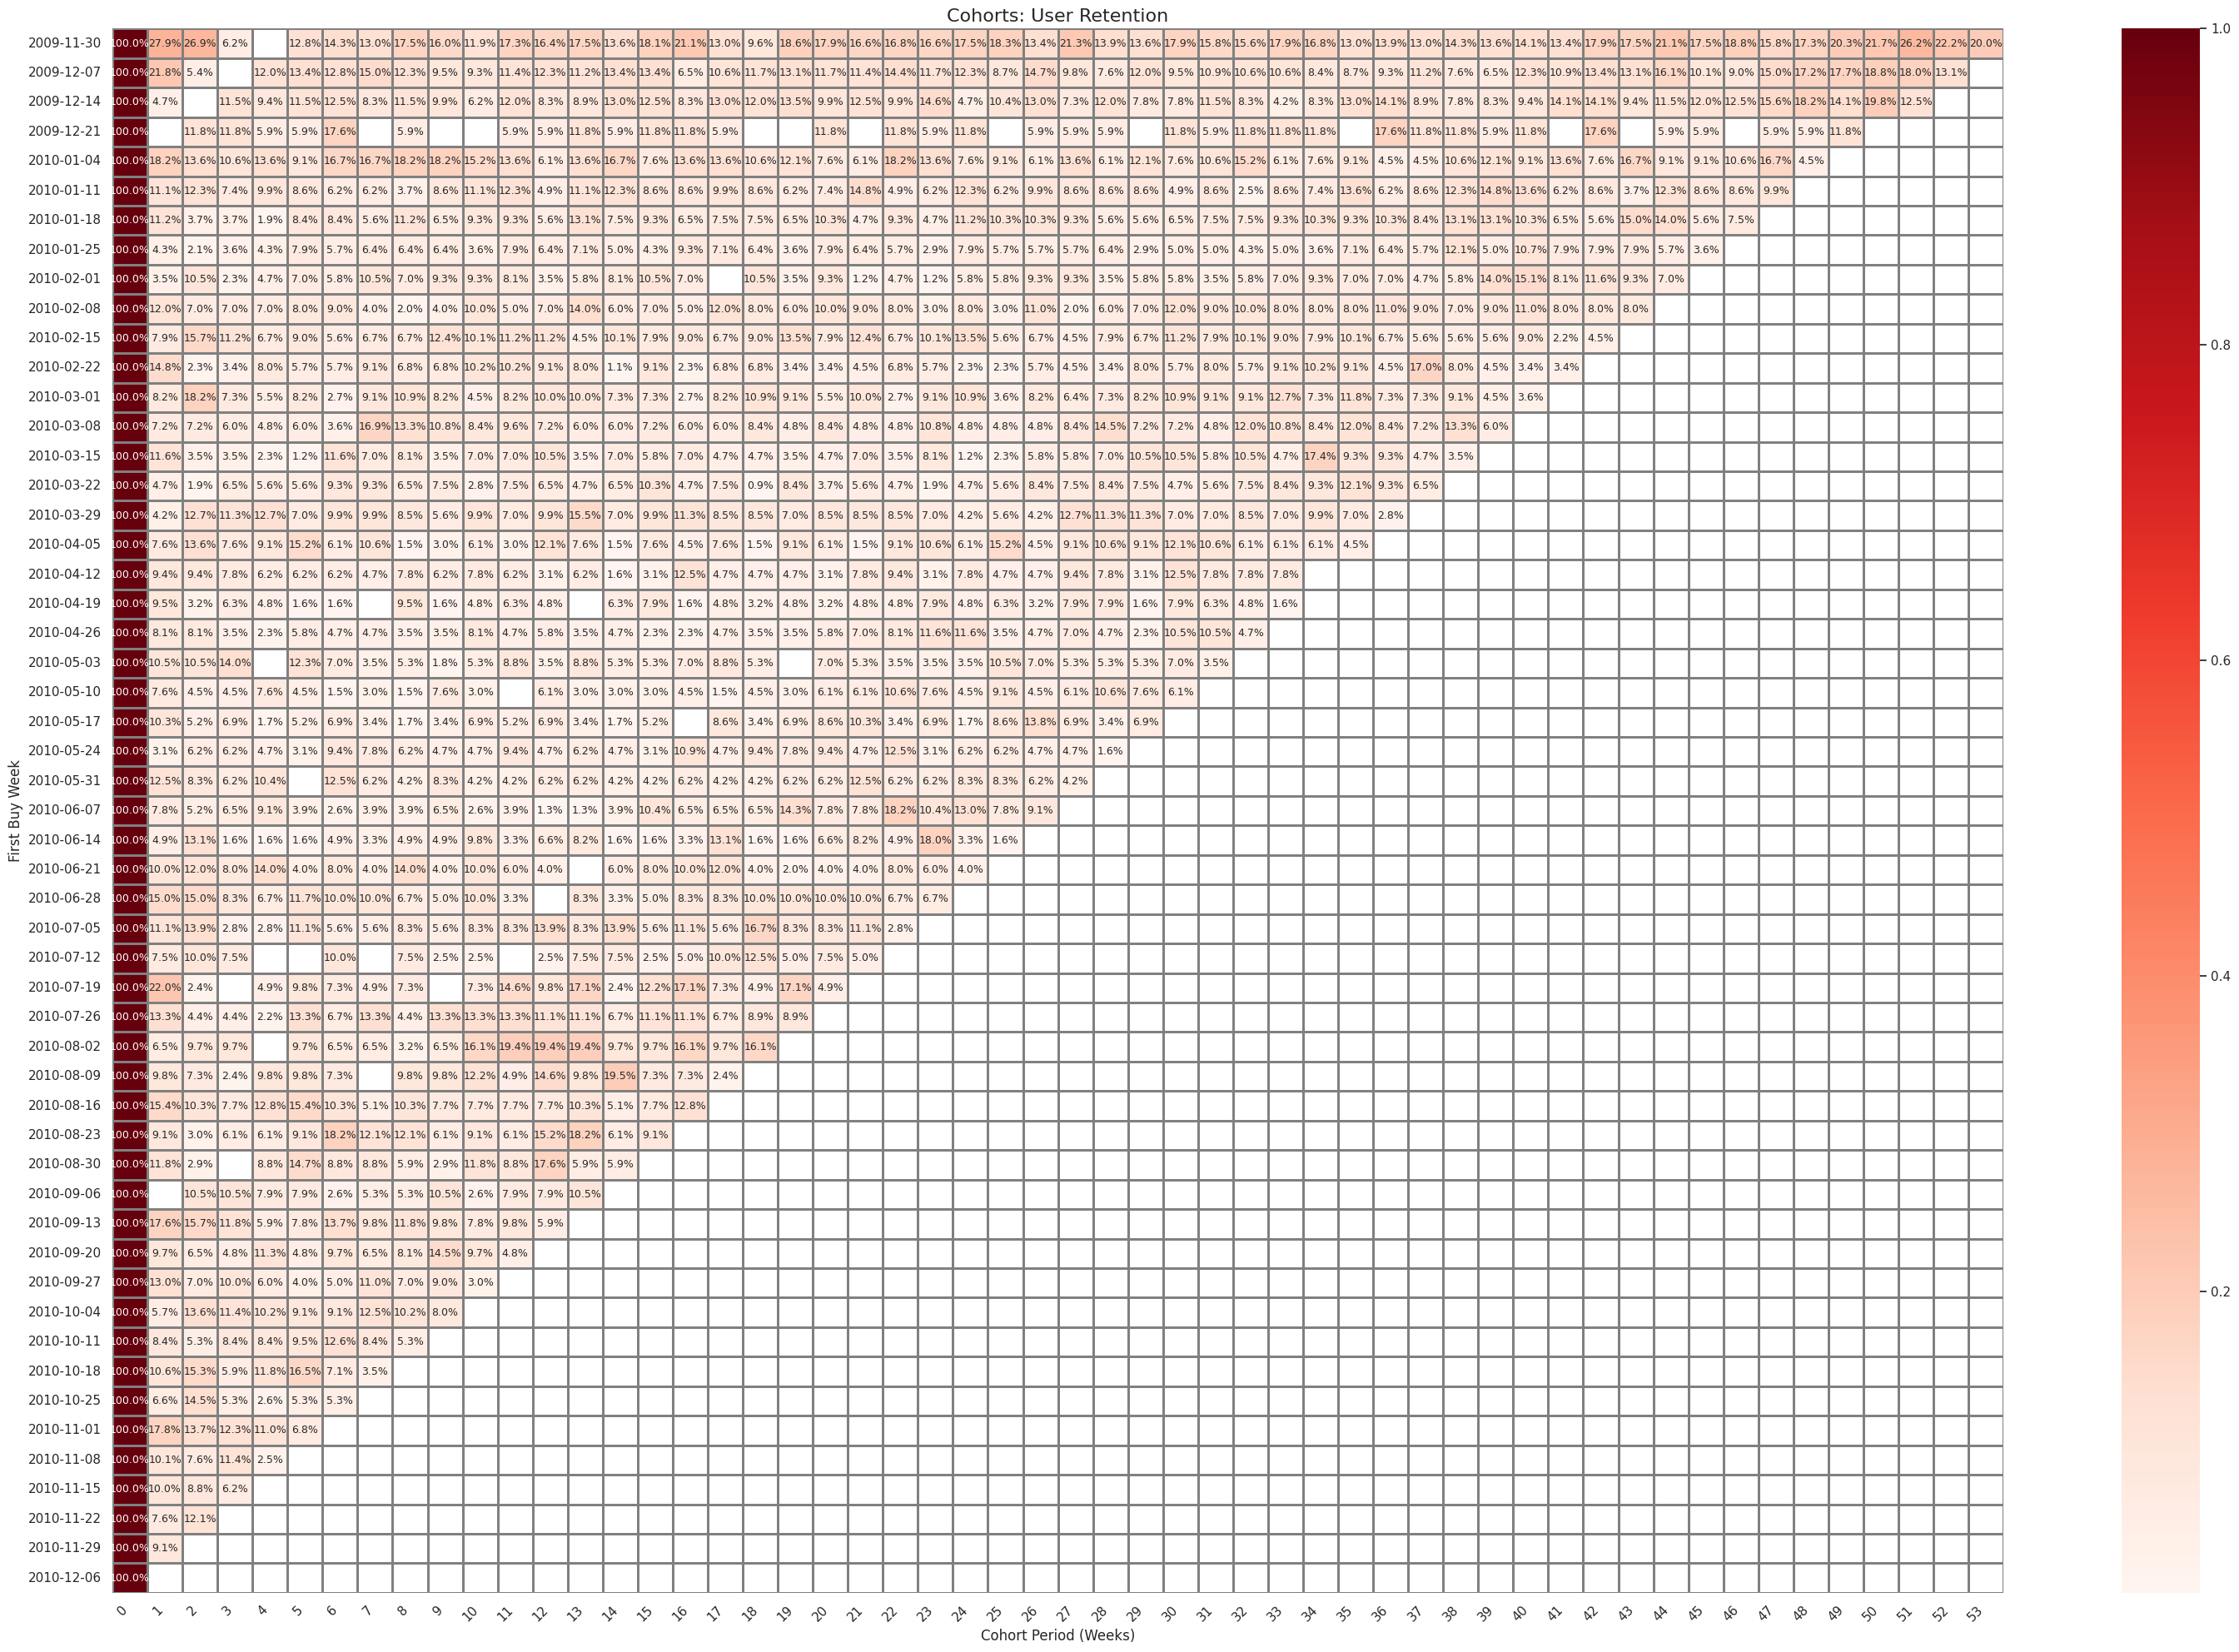

In [66]:
retention_pivot.index = pd.to_datetime(retention_pivot.index).strftime('%Y-%m-%d')
sns.set(style='white')
plt.figure(figsize=(30, 20))
plt.title('Cohorts: User Retention', fontsize=16)


sns.heatmap(retention_pivot,
    annot=True,
    fmt='.1%',
    linewidths=1,
    linecolor='gray',
    cmap='Reds',
    annot_kws={"size": 9}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.ylabel('First Buy Week')
plt.xlabel('Cohort Period (Weeks)')
plt.tight_layout()
plt.show()


## **Churn Rate**

- **Churn Rate:** Shows how many users we lost compared to the previous period.  
  Using `pct_change()` to calculate the percentage change in users.

- **Retention Rate:** Shows how many users are still active from the first period (“0th lifetime”).  

In [67]:
cohorts.head()

,first_buy_week,cohort_lifetime,customer_id,first_week_customer,retention
0,2009-11-30,0,469,469,1.000000
1,2009-11-30,1,131,469,0.279318
2,2009-11-30,2,126,469,0.268657
3,2009-11-30,3,29,469,0.061834
4,2009-11-30,5,60,469,0.127932


In [68]:
cohorts['churn_rate'] = cohorts.groupby(['first_buy_week'])['customer_id'].pct_change()
cohorts.head(10)

,first_buy_week,cohort_lifetime,customer_id,first_week_customer,retention,churn_rate
0,2009-11-30,0,469,469,1.000000,NaN
1,2009-11-30,1,131,469,0.279318,-0.720682
2,2009-11-30,2,126,469,0.268657,-0.038168
3,2009-11-30,3,29,469,0.061834,-0.769841
4,2009-11-30,5,60,469,0.127932,1.068966
5,2009-11-30,6,67,469,0.142857,0.116667
6,2009-11-30,7,61,469,0.130064,-0.089552
7,2009-11-30,8,82,469,0.174840,0.344262
8,2009-11-30,9,75,469,0.159915,-0.085366
9,2009-11-30,10,56,469,0.119403,-0.253333


The cohort with `first_buy_week = 2009-11-30` had **469 users** in the first week.  
- The `retention` column shows that only **27.9%** returned in week 1 and **6.1%** in week 3.  
- The `churn_rate` column shows week-to-week changes:  
  - Week 1: **-0.72** → 72% of users were lost compared to the previous week.  
  - Week 5: **1.07** → user count increased after week 4 (likely due to new or returning purchases).  
  - Weeks 6–10 fluctuate ±20–30%, showing both losses and gains.

<Axes: title={'center': 'Cohorts: Churn Rate'}, xlabel='cohort_lifetime', ylabel='first_buy_week'>

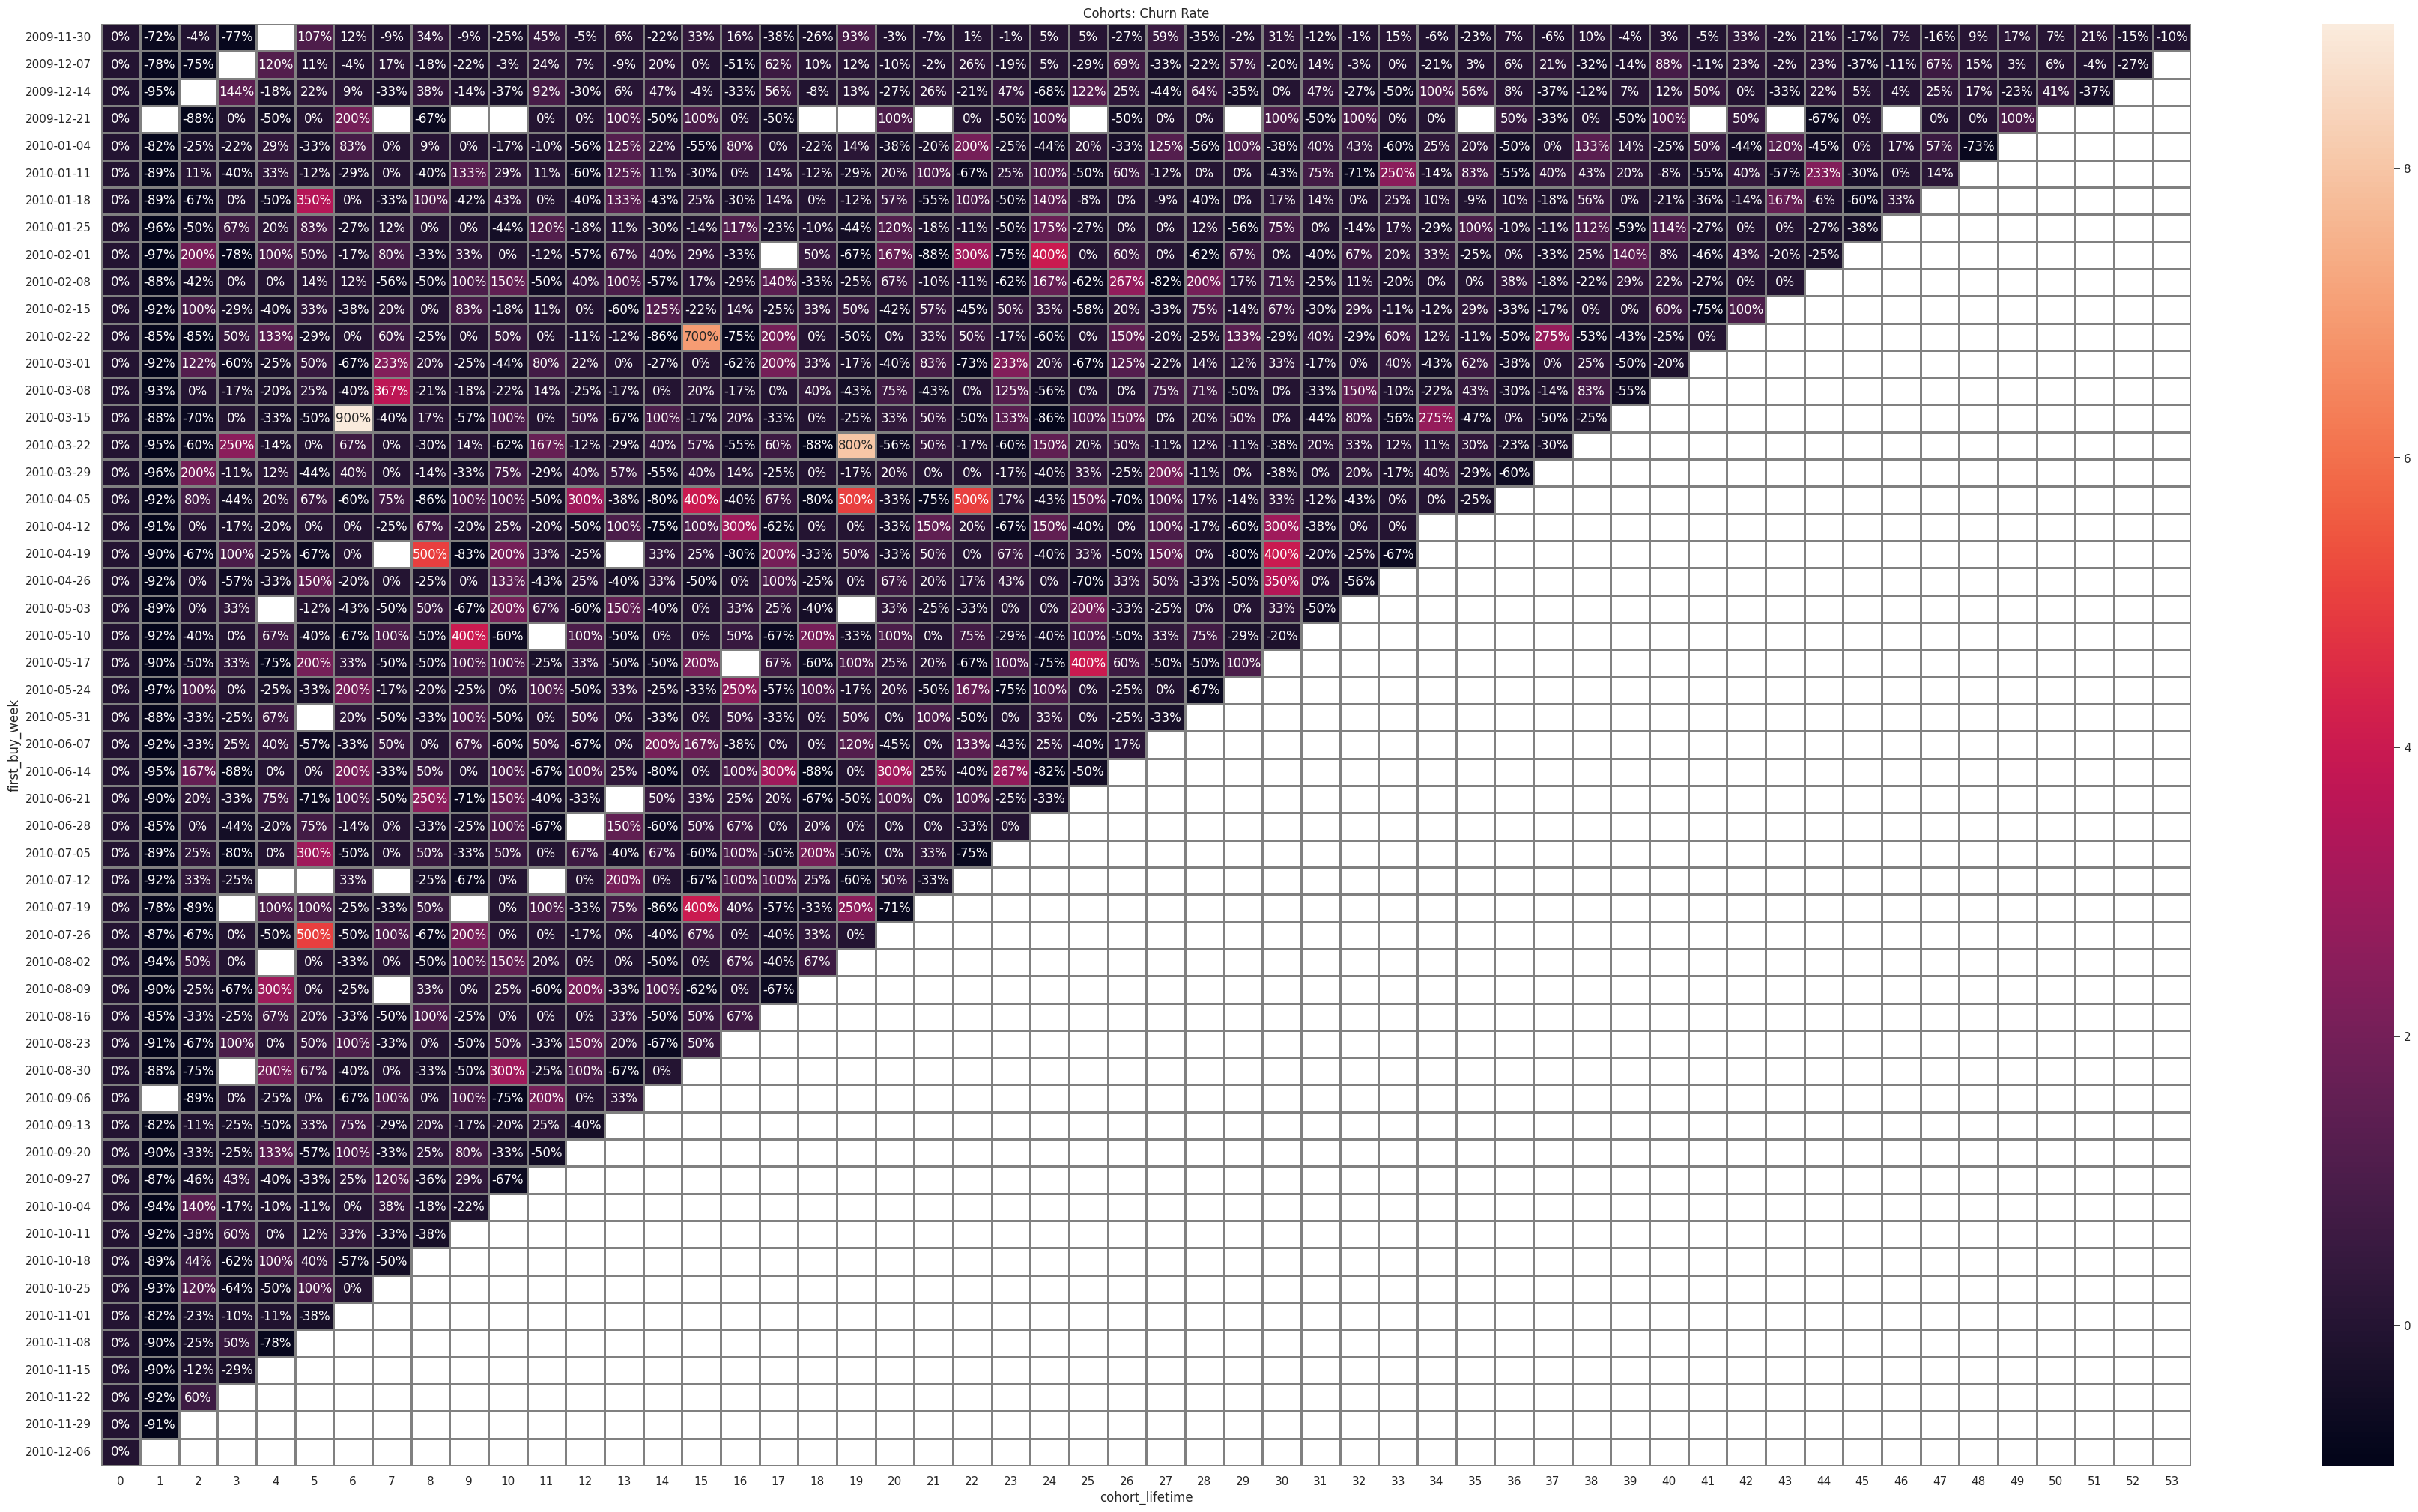

In [69]:
churn_pivot = cohorts.pivot_table(
    index='first_buy_week',
    columns='cohort_lifetime',
    values='churn_rate',
    aggfunc='sum',
)
churn_pivot.index = pd.to_datetime(churn_pivot.index).strftime('%Y-%m-%d')
sns.set(style='white')
plt.figure(figsize=(45, 25))
plt.title('Cohorts: Churn Rate')
sns.heatmap(churn_pivot, annot=True, fmt='.0%', linewidths=1, linecolor='gray')
